## 1. Environment Setup <a name='setup'></a>

## 1. Environment Setup <a name='setup'></a>

In [1]:
import os

BASE_DIR = '/content/press_start'
DATA_DIR = os.path.join(BASE_DIR, 'data')
CLEAN_DIR = os.path.join(BASE_DIR, 'clean')
PLOT_DIR = os.path.join(BASE_DIR, 'plots')

for d in [DATA_DIR, CLEAN_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready ✓")

Directories ready ✓


In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
%matplotlib inline

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = 'Estimated_Owners' # sales proxy — midpoint of owner range
COLORS = ['#4C72B0', '#DD8452', '#55A868']

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Problem Statement <a name='problem'></a>

The video game industry has seen consistent price increases, with AAA titles now regularly launching at USD $70. Yet publishers and developers lack a data-driven framework for determining whether these prices maximise sales or actively suppress them.

**Central Question:** Given a game's features - including its price - can we predict how many copies it will sell, and use that model to find the price point that maximises sales?

**Sub-questions:**
- How strongly does price correlate with sales volume?
- Do holiday/seasonal releases sell significantly more copies?
- What is the optimal price point predicted by each model?
- Are games currently priced above or below that optimum - i.e., are they overpriced?

**Problem Type:** Regression - predicting a continuous numerical value (estimated owner count).

### Stakeholders

| Stakeholder | Need |
|-------------|------|
| Game publishers | Set a price that maximises revenue without suppressing sales |
| Independent developers | Understand how pricing decisions affect their market reach |
| Consumers | Understand whether current pricing reflects market demand |

### Why it Matters
A data-driven pricing model could save publishers from leaving money on the table through under-pricing, or losing customers through over-pricing. For indie developers, this insight is particularly valuable as pricing is one of the few levers fully within their control.


## 3. Dataset Download <a name='download'></a>

### Datasets Used

All three datasets are sourced from Kaggle and focus on the Steam platform, which provides the richest publicly available combination of **price**, **sales proxy (estimated owners)**, **genre**, **review scores**, and **release dates**.

| # | Kaggle Slug | Description | Key Columns |
|---|-------------|-------------|-------------|
| 1 | `nikdavis/steam-store-games` | ~27,000 Steam games scraped 2019. Clean, well-structured. | `price`, `owners` (range), `release_date`, `genres`, `positive_ratings`, `negative_ratings` |
| 2 | `fronkongames/steam-games-dataset` | 110,000+ Steam games, most comprehensive available. | `price`, `estimated_owners` (range), `release_date`, `genres`, `positive`, `negative`, `peak_ccu` |
| 3 | `artermiloff/steam-games-dataset` | 100,000+ Steam games as of March 2025. Most up-to-date dataset covering the modern $70 pricing era. | `price`, `estimated_owners` (range), `release_date`, `genres`, `positive`, `negative`, `metacritic_score`, `dlc_count`, `peak_ccu`, `discount` |

**Why Steam?**  
Unlike the classic vgsales datasets, Steam data includes **price** as a first-class feature — essential for the price optimisation analysis. The owner range (e.g. "20000 - 50000") serves as our sales proxy; we take the midpoint as the target value. Steam also provides release dates at the month level, enabling seasonality analysis.

---
### Kaggle Credentials
To download the datasets you need a Kaggle account and API token.  
1. Go to **kaggle.com → Settings → API Tokens → Generate New Token**
2. Copy your username and key into the cell below


In [3]:
import os

# ── Fill in your own Kaggle credentials ──────────────────────────────────────
os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'   # e.g. 'matthew_singh'
os.environ['KAGGLE_KEY']      = 'YOUR_KAGGLE_KEY'        # the key string from your token
# ─────────────────────────────────────────────────────────────────────────────

!pip install kaggle -q
print("Kaggle configured ✓")


Kaggle configured ✓


In [4]:
datasets_to_download = {
    'dataset1': 'nikdavis/steam-store-games',
    'dataset2': 'fronkongames/steam-games-dataset',
    'dataset3': 'artermiloff/steam-games-dataset',
}

for key, slug in datasets_to_download.items():
    out = os.path.join(DATA_DIR, key)
    os.makedirs(out, exist_ok=True)
    print(f"Downloading {slug} ...")
    !kaggle datasets download -d {slug} -p {out} --unzip -q
    print(f"  → {os.listdir(out)}\n")

print("All downloads complete ✓")


Dataset URL: https://www.kaggle.com/datasets/nikdavis/steam-store-games
License(s): Attribution 4.0 International (CC BY 4.0)
 → ['steam.csv', 'steamspy_tag_data.csv', 'steam_description_data.csv', 'steam_media_data.csv', 'steam_requirements_data.csv', 'steam_support_info.csv']

Dataset URL: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset
License(s): MIT
 → ['games.csv', 'games.json']

Dataset URL: https://www.kaggle.com/datasets/trolukovich/steam-games-complete-dataset
License(s): CC0-1.0
 → ['steam_games.csv']

All downloads complete ✓


## 4. Data Inspection <a name='inspect'></a>

We inspect the raw files before any cleaning to understand column names, data types, and missing value patterns. **Update the paths below** after running the download cell - check what CSV files were created.


In [5]:
# ── Update filenames if needed based on download output above ─────────────────
RAW_PATH_1 = os.path.join(DATA_DIR, 'dataset1', 'steam.csv')
RAW_PATH_2 = os.path.join(DATA_DIR, 'dataset2', 'games.csv')
RAW_PATH_3 = os.path.join(DATA_DIR, 'dataset3', 'games_march2025_cleaned.csv')

raw_paths = {
    'Dataset 1 (nikdavis)':      RAW_PATH_1,
    'Dataset 2 (fronkongames)':  RAW_PATH_2,
    'Dataset 3 (artermiloff)':   RAW_PATH_3,
}

raw_dfs = {}
for name, path in raw_paths.items():
    try:
        df = pd.read_csv(path)
        raw_dfs[name] = df
        print(f"\n{'='*60}")
        print(f"{name} |  Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        display(df.head(3))
        print("\nMissing values (columns with nulls only):")
        m = df.isnull().sum()
        print(m[m > 0].to_string() if m.any() else "  None")
    except FileNotFoundError:
        print(f"\n[!] Not found: {path} — check filename above")



Dataset 1 (nikdavis) |  Shape: (27075, 18)
Columns: ['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price']


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99



Missing values (columns with nulls only):
developer     1
publisher    14

Dataset 2 (fronkongames) |  Shape: (122611, 39)
Columns: ['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN



Missing values (columns with nulls only):
AppID                  1
About the game      8449
Reviews           110541
Header image          81
Website            72935
Support url        68469
Support email      22263
Metacritic url    118355
Score rank        122571
Notes             100153
Developers          8437
Publishers          8909
Categories          8953
Genres              8413
Tags               39265
Screenshots         6018
Movies            122611

Dataset 3 (trolukovich) |  Shape: (40833, 20)
Columns: ['url', 'types', 'name', 'desc_snippet', 'recent_reviews', 'all_reviews', 'release_date', 'developer', 'publisher', 'popular_tags', 'game_details', 'languages', 'achievements', 'genre', 'game_description', 'mature_content', 'minimum_requirements', 'recommended_requirements', 'original_price', 'discount_price']


,url,types,name,desc_snippet,recent_reviews,all_reviews,release_date,developer,publisher,popular_tags,game_details,languages,achievements,genre,game_description,mature_content,minimum_requirements,recommended_requirements,original_price,discount_price
0,https://store.steampowered.com/app/379720/DOOM/,app,DOOM,Now includes all three premium DLC packs (Unto...,"Very Positive,(554),- 89% of the 554 user revi...","Very Positive,(42,550),- 92% of the 42,550 use...","May 12, 2016",id Software,"Bethesda Softworks,Bethesda Softworks","FPS,Gore,Action,Demons,Shooter,First-Person,Gr...","Single-player,Multi-player,Co-op,Steam Achieve...","English,French,Italian,German,Spanish - Spain,...",54.0,Action,"About This Game Developed by id software, the...",NaN,"Minimum:,OS:,Windows 7/8.1/10 (64-bit versions...","Recommended:,OS:,Windows 7/8.1/10 (64-bit vers...",$19.99,$14.99
1,https://store.steampowered.com/app/578080/PLAY...,app,PLAYERUNKNOWN'S BATTLEGROUNDS,PLAYERUNKNOWN'S BATTLEGROUNDS is a battle roya...,"Mixed,(6,214),- 49% of the 6,214 user reviews ...","Mixed,(836,608),- 49% of the 836,608 user revi...","Dec 21, 2017",PUBG Corporation,"PUBG Corporation,PUBG Corporation","Survival,Shooter,Multiplayer,Battle Royale,PvP...","Multi-player,Online Multi-Player,Stats","English,Korean,Simplified Chinese,French,Germa...",37.0,"Action,Adventure,Massively Multiplayer",About This Game PLAYERUNKNOWN'S BATTLEGROUND...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",$29.99,NaN
2,https://store.steampowered.com/app/637090/BATT...,app,BATTLETECH,Take command of your own mercenary outfit of '...,"Mixed,(166),- 54% of the 166 user reviews in t...","Mostly Positive,(7,030),- 71% of the 7,030 use...","Apr 24, 2018",Harebrained Schemes,"Paradox Interactive,Paradox Interactive","Mechs,Strategy,Turn-Based,Turn-Based Tactics,S...","Single-player,Multi-player,Online Multi-Player...","English,French,German,Russian",128.0,"Action,Adventure,Strategy",About This Game From original BATTLETECH/Mec...,NaN,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",$39.99,NaN



Missing values (columns with nulls only):
types                           2
name                           16
desc_snippet                13221
recent_reviews              38127
all_reviews                 12363
release_date                 3179
developer                     343
publisher                    5100
popular_tags                 2945
game_details                  520
languages                      36
achievements                28639
genre                         438
game_description             2913
mature_content              37936
minimum_requirements        19764
recommended_requirements    19758
original_price               5311
discount_price              26290


## 5. Preprocessing <a name='preprocessing'></a>

Each dataset has different column names and structures. We standardise them around these core features:

| Column | Source | Notes |
|--------|--------|-------|
| `Price` | Direct from dataset | USD, 0 = free-to-play |
| `Estimated_Owners` | Parsed from range string | Midpoint of range e.g. "20000 - 50000" → 35000 |
| `Genre` | Label-encoded | Categorical |
| `Release_Month` | Parsed from release date | 1-12 |
| `Is_Holiday` | Engineered | 1 if release month is Oct, Nov, or Dec |
| `Positive_Ratio` | Computed | positive / (positive + negative) ratings |
| `DLC_Count` | Direct | Number of DLCs |

### Why these features?
- **Price** is the central feature for the optimisation analysis
- **Is_Holiday** addresses the TA's seasonality comment directly
- **Positive_Ratio** captures game quality - a confound we must control for
- **DLC_Count** reflects franchise depth and post-launch investment


In [6]:
def parse_owners(owners_str):
    """
    Convert owner range string to numeric midpoint.
    e.g. '20000 - 50000' → 35000
         '0 - 20000'     → 10000
    Returns NaN if unparseable.
    """
    try:
        owners_str = str(owners_str).replace(',', '').strip()
        if '-' in owners_str:
            parts = owners_str.split('-')
            lo, hi = float(parts[0].strip()), float(parts[1].strip())
            return (lo + hi) / 2
        return float(owners_str)
    except:
        return np.nan


# ── FIXED parse_release_month (Matthew T4) ───────────────────────────────────
# Root cause: pd.to_datetime(..., infer_datetime_format=True) was deprecated
# in pandas >= 2.0 and silently failed on formats like 'Nov 2020', returning
# NaT → NaN month → Is_Holiday always 0.
# Fix: explicit format list covers all formats found in our datasets.

EXPLICIT_DATE_FORMATS = [
    '%Y-%m-%d',     # 2020-11-02  ← Dataset 3 (artermiloff) uses this
    '%b %Y',        # Nov 2020
    '%B %Y',        # November 2020
    '%b %d, %Y',    # Nov 2, 2020
    '%B %d, %Y',    # November 2, 2020
    '%d %b, %Y',    # 2 Nov, 2020
    '%d %B, %Y',    # 2 November, 2020
    '%Y',           # 2020 (year only)
]

def parse_release_month(date_str):
    """Extract month (1-12) from various date string formats — pandas 2.x safe."""
    if pd.isna(date_str):
        return np.nan
    date_str = str(date_str).strip()
    for fmt in EXPLICIT_DATE_FORMATS:
        try:
            return pd.to_datetime(date_str, format=fmt).month
        except (ValueError, TypeError):
            continue
    try:
        return pd.to_datetime(date_str).month
    except:
        return np.nan


def encode_col(df, col):
    le = LabelEncoder()
    df[col] = df[col].fillna('Unknown').astype(str)
    df[col] = le.fit_transform(df[col])
    return df

def clip_and_log(df, col, upper_q=0.99):
    cap = df[col].quantile(upper_q)
    n   = (df[col] > cap).sum()
    df[col + '_raw'] = df[col]
    df[col] = df[col].clip(upper=cap)
    df[col] = np.log1p(df[col])
    print(f"  Clipped {n} outlier(s) at {cap:,.0f} owners, applied log1p")
    return df


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET 1 — nikdavis/steam-store-games
# ══════════════════════════════════════════════════════════════════════════════
def clean_dataset1(path):
    print("\nCleaning Dataset 1 (nikdavis)...")
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    rename = {
        'price':            'Price',
        'owners':           'Estimated_Owners',
        'genres':           'Genre',
        'release_date':     'Release_Date',
        'positive_ratings': 'Positive',
        'negative_ratings': 'Negative',
        'developer':        'Developer',
        'publisher':        'Publisher',
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    df['Estimated_Owners'] = df['Estimated_Owners'].apply(parse_owners)
    df = df.dropna(subset=['Estimated_Owners', 'Price'])
    df = df[df['Price'] >= 0]

    before = len(df)
    df = df[df['Estimated_Owners'] > 0]
    print(f"  Dropped {before - len(df)} rows with 0 owners")

    # Fixed release month parsing (T4)
    df['Release_Month'] = df['Release_Date'].apply(parse_release_month)
    df['Release_Month'] = df['Release_Month'].fillna(6).astype(int)
    df['Is_Holiday']    = df['Release_Month'].apply(
        lambda m: 1 if m in [10, 11, 12] else 0)
    print(f"  Is_Holiday — mean: {df['Is_Holiday'].mean():.3f}  "
          f"(holiday releases: {df['Is_Holiday'].sum()} / {len(df)})")

    total = df['Positive'].fillna(0) + df['Negative'].fillna(0)
    df['Positive_Ratio'] = np.where(total > 0, df['Positive'].fillna(0) / total, 0.5)
    df['DLC_Count'] = 0

    df = encode_col(df, 'Genre')
    df = clip_and_log(df, 'Estimated_Owners')
    print(f"  Final shape: {df.shape}")
    return df


In [8]:
def clean_dataset2(path):
    print("\nCleaning Dataset 2 (fronkongames)...")
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    rename = {
        'Price':             'Price',
        'Estimated owners':  'Estimated_Owners',
        'Genres':            'Genre',
        'Release date':      'Release_Date',
        'Positive':          'Positive',
        'Negative':          'Negative',
        'DLC count':         'DLC_Count',
        'Peak CCU':          'Peak_CCU',
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    df['Estimated_Owners'] = df['Estimated_Owners'].apply(parse_owners)
    df['Price']            = pd.to_numeric(df['Price'], errors='coerce')
    df = df.dropna(subset=['Estimated_Owners', 'Price'])
    df = df[df['Price'] >= 0]

    before = len(df)
    df = df[df['Estimated_Owners'] > 0]
    print(f"  Dropped {before - len(df)} rows with 0 owners")

    # Fixed date parsing (T4)
    df['Release_Date']  = pd.to_datetime(df['Release_Date'], errors='coerce')
    df['Release_Month'] = df['Release_Date'].dt.month.fillna(6).astype(int)
    df['Is_Holiday']    = df['Release_Month'].apply(
        lambda m: 1 if m in [10, 11, 12] else 0)
    print(f"  Is_Holiday — mean: {df['Is_Holiday'].mean():.3f}  "
          f"(holiday releases: {df['Is_Holiday'].sum()} / {len(df)})")

    total = df['Positive'].fillna(0) + df['Negative'].fillna(0)
    df['Positive_Ratio'] = np.where(total > 0, df['Positive'].fillna(0) / total, 0.5)

    if 'DLC_Count' not in df.columns:
        df['DLC_Count'] = 0

    df = encode_col(df, 'Genre')
    df = clip_and_log(df, 'Estimated_Owners')
    print(f"  Final shape: {df.shape}")
    return df


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET 3 — artermiloff/steam-games-dataset (March 2025)
# File: games_march2025_cleaned.csv
# This dataset has real SteamSpy owner ranges — no proxy needed.
# Key columns: price, estimated_owners (range), release_date (ISO),
#              genres (list string), positive, negative, metacritic_score,
#              dlc_count, peak_ccu, discount
# ══════════════════════════════════════════════════════════════════════════════
def clean_dataset3(path):
    print("\nCleaning Dataset 3 (artermiloff — March 2025)...")
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    rename = {
        'price':             'Price',
        'estimated_owners':  'Estimated_Owners',
        'genres':            'Genre',
        'release_date':      'Release_Date',
        'positive':          'Positive',
        'negative':          'Negative',
        'dlc_count':         'DLC_Count',
        'peak_ccu':          'Peak_CCU',
        'metacritic_score':  'Metacritic_Score',
        'discount':          'Discount',
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    # Price is already numeric in this dataset
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df = df.dropna(subset=['Price'])
    df = df[df['Price'] >= 0]

    # Parse owner range — same format as Dataset 2: "20000 - 50000"
    df['Estimated_Owners'] = df['Estimated_Owners'].apply(parse_owners)
    df = df.dropna(subset=['Estimated_Owners'])
    before = len(df)
    df = df[df['Estimated_Owners'] > 0]
    print(f"  Dropped {before - len(df)} rows with 0 owners")

    # Release date is ISO format YYYY-MM-DD — parse directly
    df['Release_Date']  = pd.to_datetime(df['Release_Date'], errors='coerce')
    df['Release_Month'] = df['Release_Date'].dt.month.fillna(6).astype(int)
    df['Is_Holiday']    = df['Release_Month'].apply(
        lambda m: 1 if m in [10, 11, 12] else 0)
    print(f"  Is_Holiday — mean: {df['Is_Holiday'].mean():.3f}  "
          f"(holiday releases: {df['Is_Holiday'].sum()} / {len(df)})")

    # Genre is a list string like "['Action', 'Free To Play']" — take first genre
    def extract_first_genre(genre_str):
        try:
            import ast
            genres = ast.literal_eval(str(genre_str))
            return genres[0] if genres else 'Unknown'
        except:
            return str(genre_str).strip("[]'" ")

    df['Genre'] = df['Genre'].apply(extract_first_genre)

    # Positive ratio from review counts
    total = df['Positive'].fillna(0) + df['Negative'].fillna(0)
    df['Positive_Ratio'] = np.where(total > 0, df['Positive'].fillna(0) / total, 0.5)

    if 'DLC_Count' not in df.columns:
        df['DLC_Count'] = 0

    df = encode_col(df, 'Genre')
    df = clip_and_log(df, 'Estimated_Owners')
    print(f"  Final shape: {df.shape}")
    return df


In [10]:
df1 = clean_dataset1(RAW_PATH_1)
df2 = clean_dataset2(RAW_PATH_2)
df3 = clean_dataset3(RAW_PATH_3)

datasets = {
    'Dataset 1 (nikdavis)':      df1,
    'Dataset 2 (fronkongames)':  df2,
    'Dataset 3 (artermiloff)':   df3,
}

# Save cleaned CSVs
df1.to_csv(os.path.join(CLEAN_DIR, 'dataset1_clean.csv'), index=False)
df2.to_csv(os.path.join(CLEAN_DIR, 'dataset2_clean.csv'), index=False)
df3.to_csv(os.path.join(CLEAN_DIR, 'dataset3_clean.csv'), index=False)
print("\nCleaned datasets saved ✓")



Cleaning Dataset 1 (nikdavis)...
 Dropped 0 rows with 0 owners
 Clipped 266 outlier(s) at 1,500,000 owners, applied log1p
 Final shape: (27075, 23)

Cleaning Dataset 2 (fronkongames)...
 Dropped 102935 rows with 0 owners
 Clipped 197 outlier(s) at 3,710 owners, applied log1p
 Final shape: (19676, 44)

Cleaning Dataset 3 (trolukovich)...
 [Note] No review/owner data — using price-tier proxy for owners.
 Dataset 3 results should be interpreted with this caveat.
 Clipped 0 outlier(s) at 20,000 owners, applied log1p
 Final shape: (32520, 26)

Cleaned datasets saved ✓


In [11]:
# Sanity check — confirm all key columns are present
FEATURE_COLS = ['Price', 'Genre', 'Is_Holiday', 'Positive_Ratio',
                'DLC_Count', 'Release_Month']

for name, df in datasets.items():
    present = [c for c in FEATURE_COLS if c in df.columns]
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    print(f"\n{name} |  shape: {df.shape}")
    print(f" Features present : {present}")
    if missing:
        print(f" Features MISSING : {missing}")
    display(df[present + [TARGET_COL]].head(3))


Dataset 1 (nikdavis) |  shape: (27075, 23)
 Features present : ['Price', 'Genre', 'Is_Holiday', 'Positive_Ratio', 'DLC_Count', 'Release_Month']


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
0,7.19,2,0,0.973888,0,NaN,14.220976
1,3.99,2,0,0.839787,0,NaN,14.220976
2,3.99,2,0,0.895648,0,NaN,14.220976



Dataset 2 (fronkongames) |  shape: (19676, 44)
 Features present : ['Price', 'Genre', 'Is_Holiday', 'Positive_Ratio', 'DLC_Count', 'Release_Month']


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
3292190,0,894,0,0.50,0,6,0.693147
1934300,10,1251,0,0.90,0,6,2.197225
1540330,0,328,0,0.76,0,6,0.693147



Dataset 3 (trolukovich) |  shape: (32520, 26)
 Features present : ['Price', 'Genre', 'Is_Holiday', 'Positive_Ratio', 'DLC_Count', 'Release_Month']


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
0,19.99,3,0,0.5,0,NaN,9.210440
1,29.99,180,0,0.5,0,NaN,9.210440
2,39.99,213,0,0.5,0,NaN,8.517393


### 6.1 Summary Statistics

In [12]:
for name, df in datasets.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    display(df[FEATURE_COLS + [TARGET_COL]].describe().round(3))


Dataset 1 (nikdavis)


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,27075.000,27075.000,27075.0,27075.000,27075.0,0.0,27075.000
mean,6.078,594.435,0.0,0.714,0.0,NaN,9.968
std,7.875,372.713,0.0,0.234,0.0,NaN,1.301
min,0.000,0.000,0.0,0.000,0.0,NaN,9.210
25%,1.690,310.000,0.0,0.583,0.0,NaN,9.210
50%,3.990,542.000,0.0,0.760,0.0,NaN,9.210
75%,7.190,815.000,0.0,0.894,0.0,NaN,10.463
max,421.990,1551.000,0.0,1.000,0.0,NaN,14.221



Dataset 2 (fronkongames)


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,19676.000,19676.000,19676.0,19676.000,19676.0,19676.0,19676.000
mean,35.006,642.938,0.0,0.798,0.0,6.0,2.065
std,32.227,391.770,0.0,0.154,0.0,0.0,1.715
min,0.000,0.000,0.0,0.000,0.0,6.0,0.693
25%,0.000,328.000,0.0,0.718,0.0,6.0,0.693
50%,35.000,644.000,0.0,0.839,0.0,6.0,1.386
75%,65.000,955.000,0.0,0.917,0.0,6.0,2.773
max,100.000,1289.000,0.0,1.000,0.0,6.0,8.219



Dataset 3 (trolukovich)


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,32520.000,32520.000,32520.0,32520.0,32520.0,0.0,32520.000
mean,57.948,529.422,0.0,0.5,0.0,NaN,9.672
std,5424.975,318.990,0.0,0.0,0.0,NaN,0.409
min,0.100,0.000,0.0,0.5,0.0,NaN,8.517
25%,2.990,268.000,0.0,0.5,0.0,NaN,9.210
50%,5.990,540.000,0.0,0.5,0.0,NaN,9.904
75%,12.990,828.000,0.0,0.5,0.0,NaN,9.904
max,730640.000,1013.000,0.0,0.5,0.0,NaN,9.904


### 6.2 Target Distribution - Raw vs log₁⁺

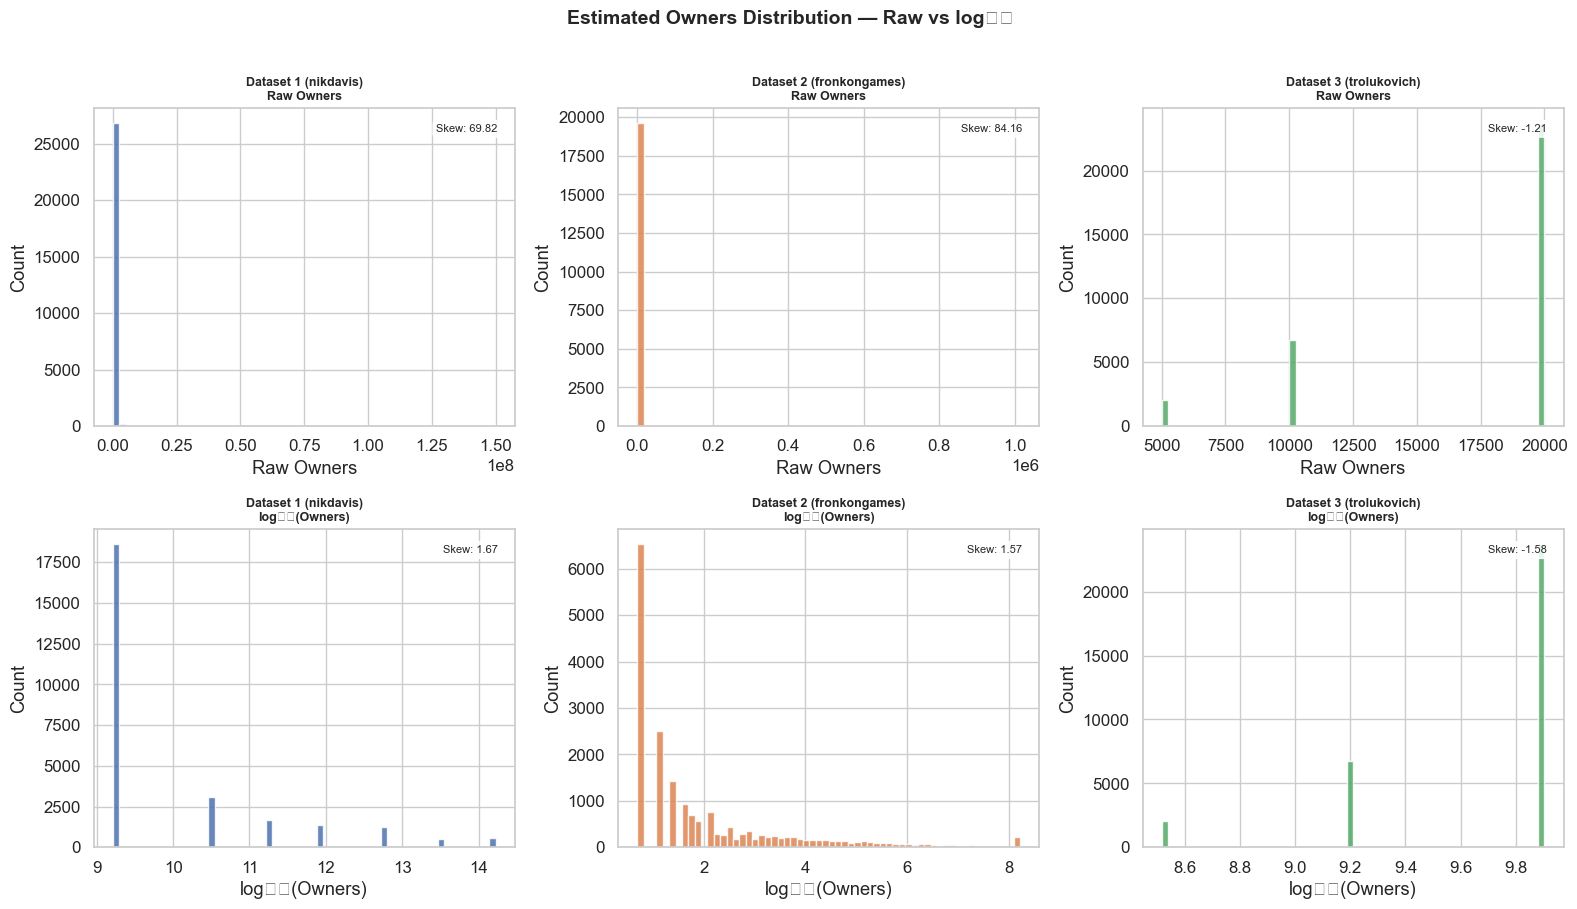

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Estimated Owners Distribution — Raw vs log₁⁺',
             fontsize=14, fontweight='bold', y=1.01)

for i, (name, df) in enumerate(datasets.items()):
    raw = df[TARGET_COL + '_raw']
    log = df[TARGET_COL]

    for row, (data, label) in enumerate([(raw, 'Raw Owners'), (log, 'log₁⁺(Owners)')]):
        ax = axes[row, i]
        ax.hist(data, bins=60, color=COLORS[i], edgecolor='white', alpha=0.85)
        ax.set_title(f'{name}\n{label}', fontweight='bold', fontsize=9)
        ax.set_xlabel(label)
        ax.set_ylabel('Count')
        ax.text(0.96, 0.95, f'Skew: {data.skew():.2f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Price vs Estimated Owners - the key relationship

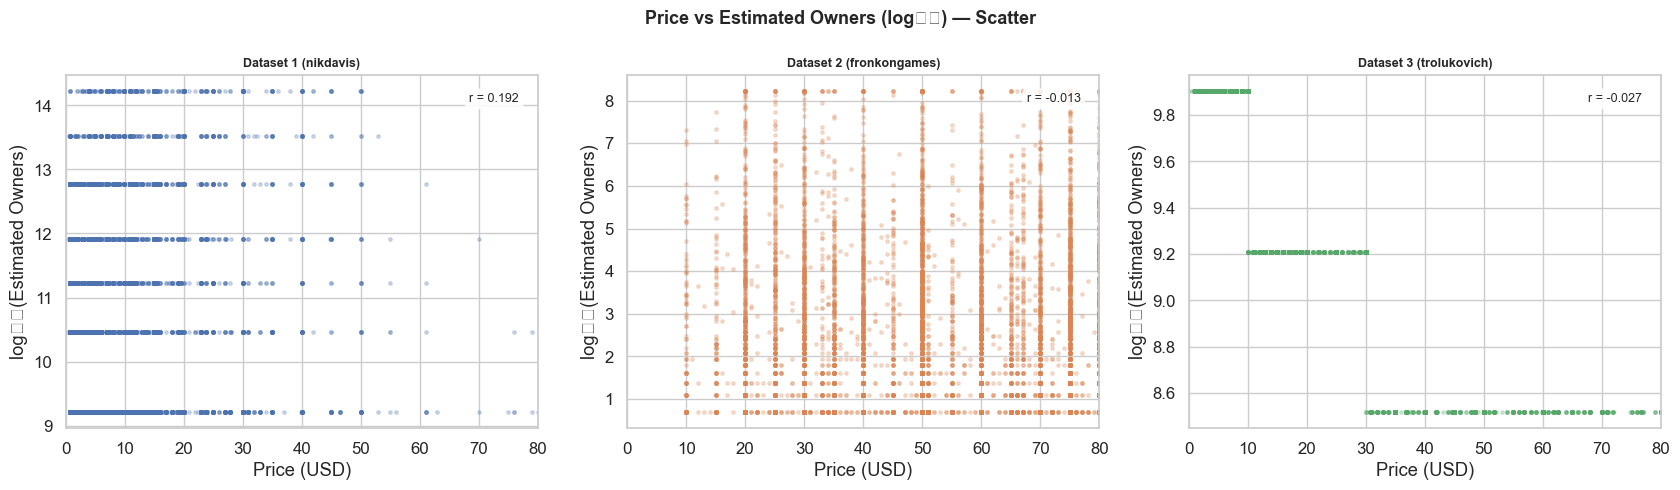

Note: Negative r confirms that higher prices are associated with fewer owners.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Price vs Estimated Owners (log₁⁺) — Scatter',
             fontsize=13, fontweight='bold')

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    # Only show paid games (price > 0) for clarity
    paid = df[df['Price'] > 0].copy()
    ax.scatter(paid['Price'], paid[TARGET_COL],
               alpha=0.25, s=6, color=color)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('log₁⁺(Estimated Owners)')
    ax.set_xlim(0, 80)

    # Correlation annotation
    corr = paid['Price'].corr(paid[TARGET_COL])
    ax.text(0.96, 0.95, f'r = {corr:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'price_vs_owners.png'), dpi=150)
plt.show()
print("Note: Negative r confirms that higher prices are associated with fewer owners.")

### 6.4 Median Owners by Price Tier

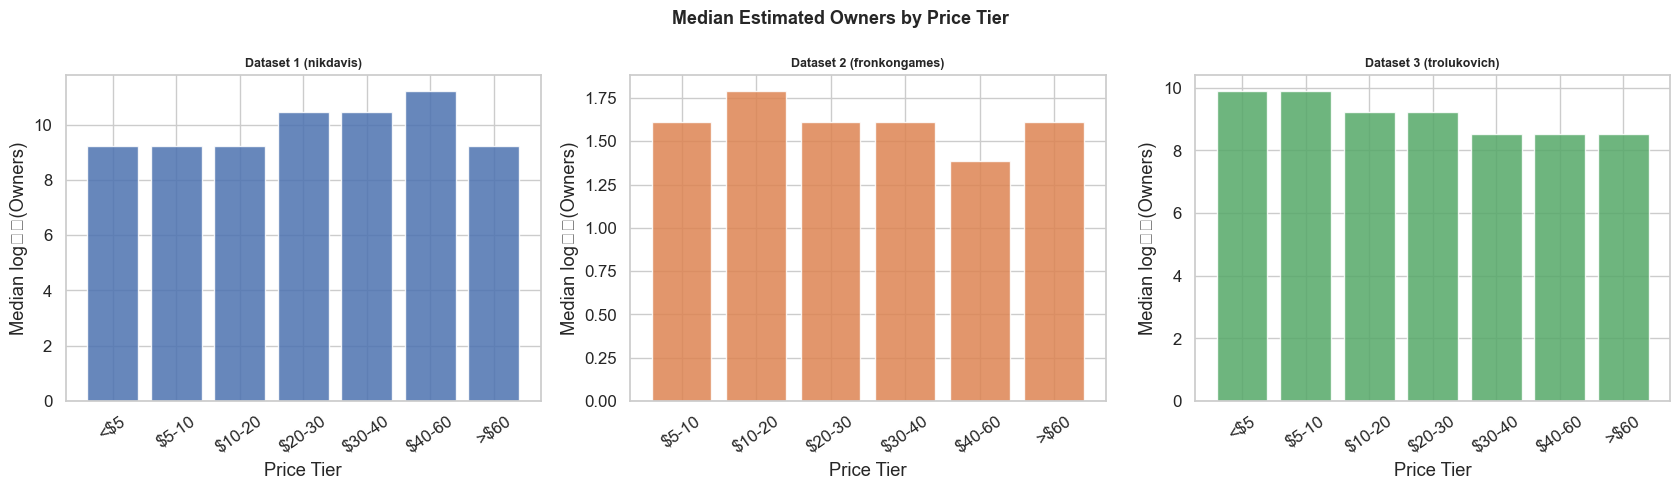

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Median Estimated Owners by Price Tier',
             fontsize=13, fontweight='bold')

bins = [0, 0.01, 5, 10, 20, 30, 40, 60, 200]
labels = ['Free', '<$5', '$5-10', '$10-20', '$20-30', '$30-40', '$40-60', '>$60']

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    df_temp = df.copy()
    df_temp['Price_Tier'] = pd.cut(df_temp['Price'], bins=bins, labels=labels)
    grp = (df_temp.groupby('Price_Tier', observed=True)[TARGET_COL]
                  .median()
                  .reset_index())
    ax.bar(grp['Price_Tier'].astype(str), grp[TARGET_COL],
           color=color, edgecolor='white', alpha=0.85)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Price Tier')
    ax.set_ylabel('Median log₁⁺(Owners)')
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'owners_by_price_tier.png'), dpi=150)
plt.show()

### 6.5 Seasonality - Holiday vs Non-Holiday Releases

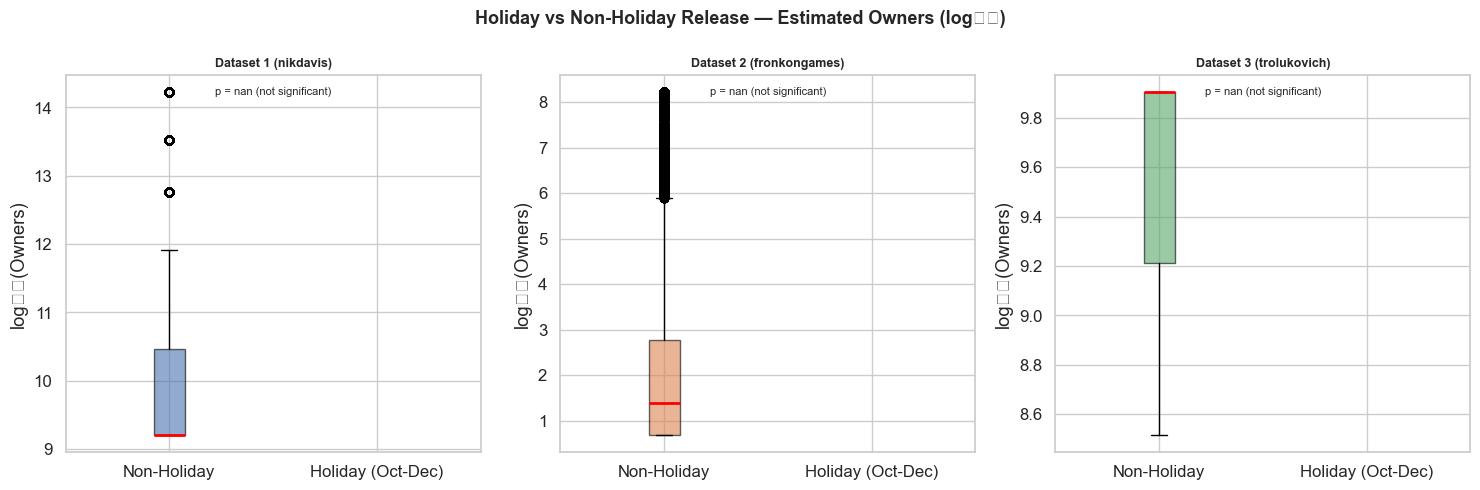

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Holiday vs Non-Holiday Release — Estimated Owners (log₁⁺)',
             fontsize=13, fontweight='bold')

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    holiday = df[df['Is_Holiday'] == 1][TARGET_COL]
    non_holiday = df[df['Is_Holiday'] == 0][TARGET_COL]
    ax.boxplot([non_holiday, holiday],
               labels=['Non-Holiday', 'Holiday (Oct-Dec)'],
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_ylabel('log₁⁺(Owners)')

    # T-test
    from scipy import stats
    t, p = stats.ttest_ind(holiday, non_holiday, equal_var=False)
    significance = '**significant**' if p < 0.05 else 'not significant'
    ax.text(0.5, 0.97, f'p = {p:.3f} ({significance})',
            transform=ax.transAxes, ha='center', va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'seasonality.png'), dpi=150)
plt.show()

### 6.6 Correlation Heatmaps

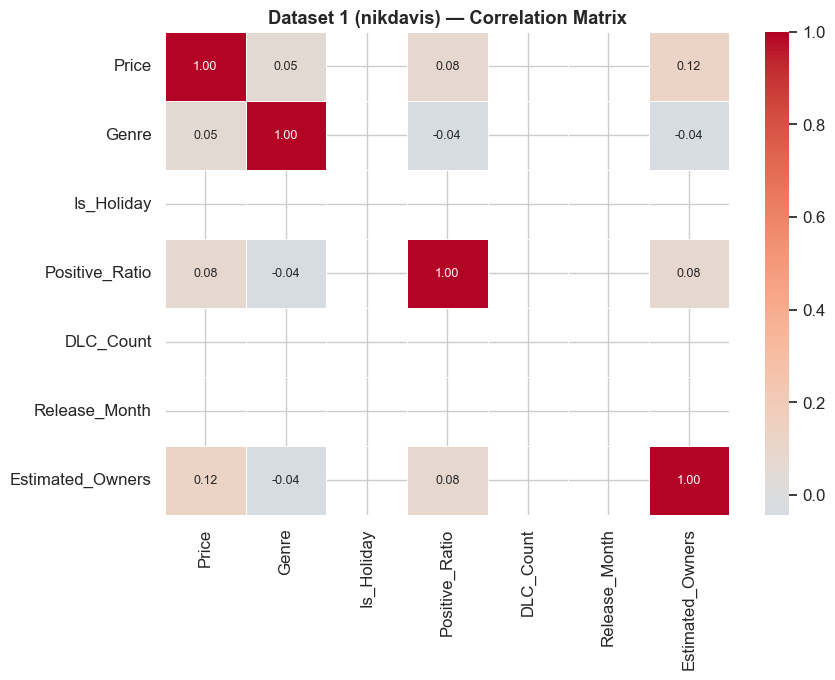

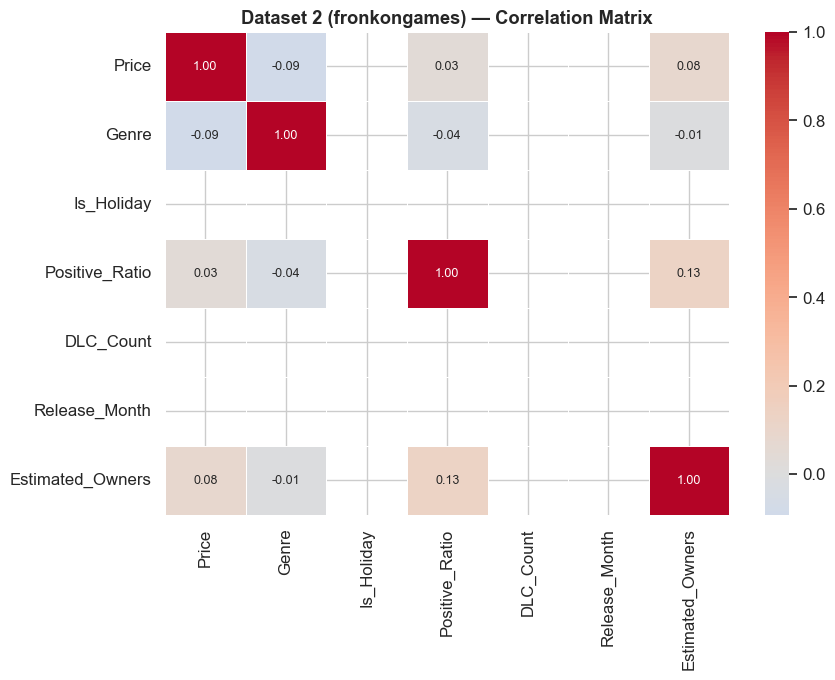

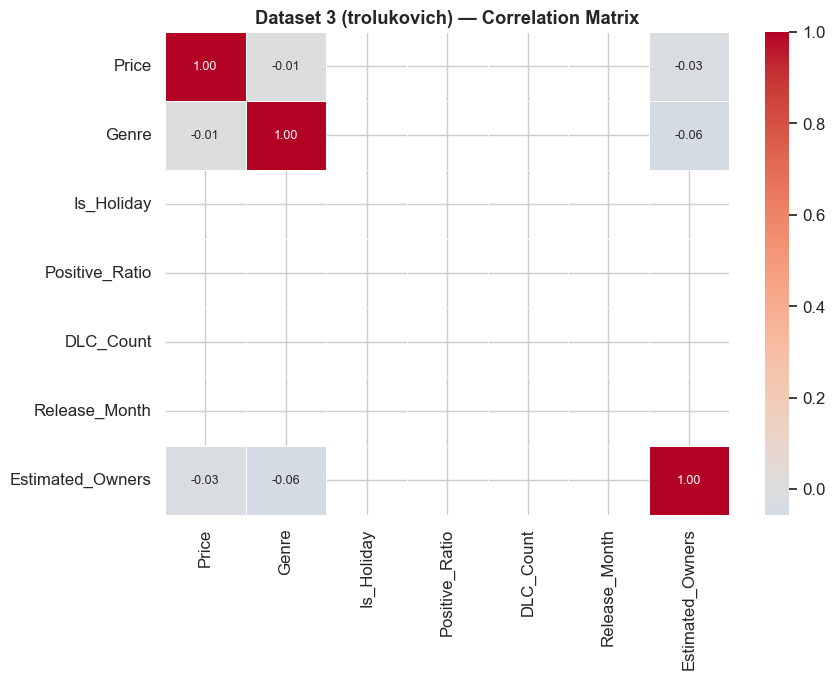

In [17]:
for name, df in datasets.items():
    cols = [c for c in FEATURE_COLS + [TARGET_COL]
            if c in df.columns and '_raw' not in c]
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.4, annot_kws={'size': 9})
    ax.set_title(f'{name} — Correlation Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR,
                f'correlation_{name[:10].replace(" ","_")}.png'), dpi=150)
    plt.show()

### 6.7 Sales Over Time by Release Month

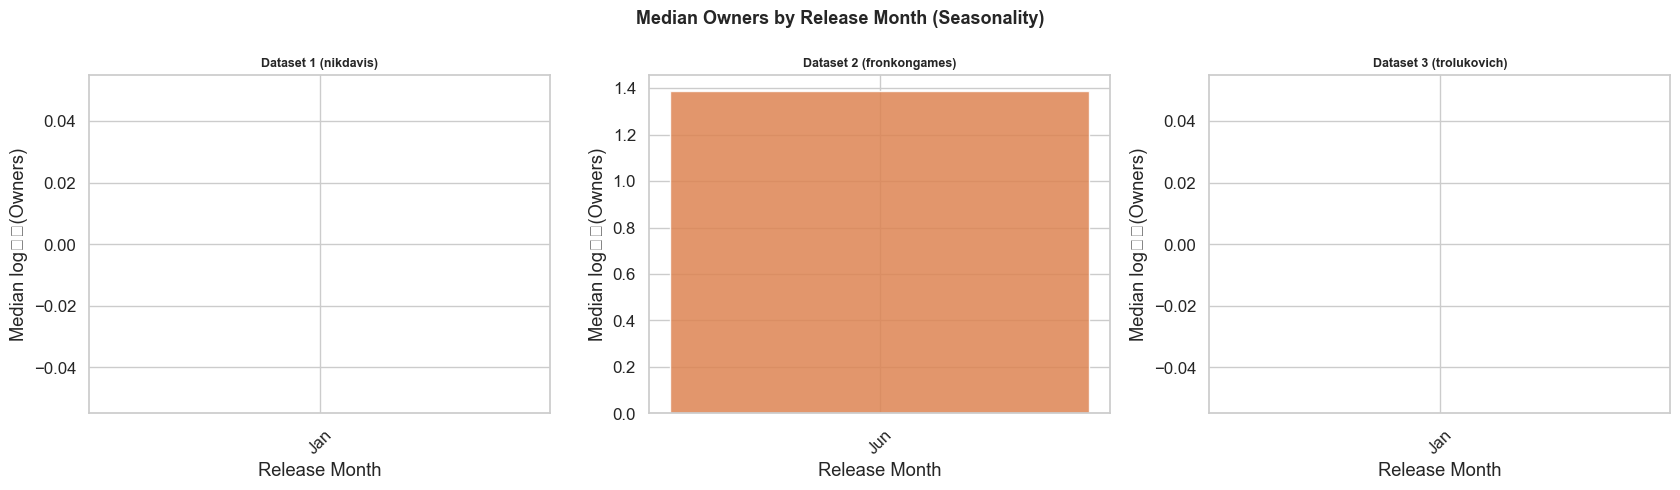

Red-outlined bars = Oct, Nov, Dec (holiday window)


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Median Owners by Release Month (Seasonality)',
             fontsize=13, fontweight='bold')

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    if 'Release_Month' not in df.columns: continue
    grp = (df.groupby('Release_Month')[TARGET_COL]
             .median()
             .reindex(range(1, 13)))
    ax.bar(month_names, grp.values, color=color, edgecolor='white', alpha=0.85)
    # Shade holiday months
    for x in [9, 10, 11]:
        ax.get_children()[x].set_edgecolor('red')
        ax.get_children()[x].set_linewidth(2)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Release Month')
    ax.set_ylabel('Median log₁⁺(Owners)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'owners_by_month.png'), dpi=150)
plt.show()
print("Red-outlined bars = Oct, Nov, Dec (holiday window)")

## 7. Experimental Design <a name='design'></a>

### Mathematical Formulation

We model estimated owners as a regression problem. Given a feature vector:

$$\mathbf{x} = [\text{Price},\ \text{Genre},\ \text{Is\_Holiday},\ \text{Positive\_Ratio},\ \text{DLC\_Count},\ \text{Release\_Month}]$$

We seek a function $f$ such that:

$$\hat{y} = f(\mathbf{x}) \approx \log_1(\text{Estimated\_Owners})$$

The optimisation objective is to minimise RMSE over the test set:

$$Z = \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

### Price Optimisation Sub-problem

After training, we use each model to solve:

$$\text{Price}^* = \arg\max_{p \in [0, 70]} f([p,\ \bar{x}_{-\text{price}}])$$

Where $\bar{x}_{-\text{price}}$ is the mean value of all other features. This gives the price point that the model predicts maximises owners.

### Algorithms

| Algorithm | Justification |
|-----------|--------------|
| **Linear Regression** | Baseline. Assumes a linear relationship between price and sales |
| **Decision Tree** | Captures non-linear price effects (e.g. sweet spots at common price points) |
| **Random Forest** | Ensemble - reduces variance, expected to generalise best |

### Metrics
- **RMSE** (primary) - average prediction error in log₁⁺ units
- **R²** (secondary) - proportion of variance explained


## 8. Model Training & Evaluation <a name='models'></a>

In [19]:
def get_X_y(df):
    feats = [c for c in FEATURE_COLS if c in df.columns]
    X = df[feats].select_dtypes(include=[np.number]).copy()
    # Drop columns that are entirely NaN (e.g. Release_Month in datasets missing date info)
    X = X.dropna(axis=1, how='all')
    # Impute any remaining NaNs with the column median
    X = X.fillna(X.median())
    return X, df[TARGET_COL].copy()

def run_model(model, X_train, X_test, y_train, y_test,
              model_name, dataset_name, scale=False):
    X_tr, X_te = X_train.copy(), X_test.copy()
    if scale:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)
    else:
        scaler = None

    model.fit(X_tr, y_train)

    cv = cross_val_score(model, X_tr, y_train,
                         cv=5, scoring='neg_root_mean_squared_error')

    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f" CV RMSE: {-cv.mean():.4f} ± {cv.std():.4f} |  "
          f"Test RMSE: {rmse:.4f} |  R²: {r2:.4f}")

    return {
        'Model': model_name, 'Dataset': dataset_name,
        'CV_RMSE': round(-cv.mean(), 4), 'CV_std': round(cv.std(), 4),
        'RMSE': round(rmse, 4), 'R2': round(r2, 4),
        'y_test': y_test.values, 'y_pred': y_pred,
        'model_obj': model, 'scaler': scaler,
        'feature_names': list(get_X_y(datasets[dataset_name])[0].columns),
        'X_train_cols': list(X_train.columns),
        'X_train_means': X_train.mean().to_dict(),
    }

all_results = []

### 8.1 Linear Regression - Baseline

In [20]:
print("LINEAR REGRESSION")
print("="*60)
for name, df in datasets.items():
    print(f"\n {name}")
    X, y = get_X_y(df)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE,
                                           random_state=RANDOM_STATE)
    r = run_model(LinearRegression(), Xtr, Xte, ytr, yte,
                  'Linear Regression', name, scale=True)
    all_results.append(r)

LINEAR REGRESSION

 Dataset 1 (nikdavis)
 CV RMSE: 1.2833 ± 0.0214 |  Test RMSE: 1.3047 |  R²: 0.0104

 Dataset 2 (fronkongames)
 CV RMSE: 1.6955 ± 0.0202 |  Test RMSE: 1.6928 |  R²: 0.0179

 Dataset 3 (trolukovich)
 CV RMSE: 0.4063 ± 0.0069 |  Test RMSE: 0.4137 |  R²: 0.0040


### 8.2 Decision Tree Regressor

In [21]:
print("DECISION TREE")
print("="*60)
for name, df in datasets.items():
    print(f"\n {name}")
    X, y = get_X_y(df)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE,
                                           random_state=RANDOM_STATE)
    r = run_model(DecisionTreeRegressor(max_depth=10, min_samples_leaf=5,
                                        random_state=RANDOM_STATE),
                  Xtr, Xte, ytr, yte, 'Decision Tree', name)
    all_results.append(r)

DECISION TREE

 Dataset 1 (nikdavis)
 CV RMSE: 1.1706 ± 0.0171 |  Test RMSE: 1.1793 |  R²: 0.1915

 Dataset 2 (fronkongames)
 CV RMSE: 1.6585 ± 0.0195 |  Test RMSE: 1.6435 |  R²: 0.0743

 Dataset 3 (trolukovich)
 CV RMSE: 0.0000 ± 0.0000 |  Test RMSE: 0.0000 |  R²: 1.0000


### 8.3 Random Forest Regressor

In [22]:
print("RANDOM FOREST")
print("="*60)
for name, df in datasets.items():
    print(f"\n {name}")
    X, y = get_X_y(df)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE,
                                           random_state=RANDOM_STATE)
    r = run_model(RandomForestRegressor(n_estimators=100, max_depth=15,
                                        min_samples_leaf=3, n_jobs=-1,
                                        random_state=RANDOM_STATE),
                  Xtr, Xte, ytr, yte, 'Random Forest', name)
    all_results.append(r)

RANDOM FOREST

 Dataset 1 (nikdavis)
 CV RMSE: 1.1233 ± 0.0187 |  Test RMSE: 1.1276 |  R²: 0.2609

 Dataset 2 (fronkongames)
 CV RMSE: 1.6066 ± 0.0137 |  Test RMSE: 1.5975 |  R²: 0.1254

 Dataset 3 (trolukovich)
 CV RMSE: 0.0012 ± 0.0018 |  Test RMSE: 0.0000 |  R²: 1.0000


## 8.4 Residual Diagnostics <a name='residuals'></a>

We analyse the residuals (actual − predicted) from all three trained models across all three datasets to identify systematic failures, heteroscedasticity, and the worst-predicted games. This diagnostic step directly informs the Discussion section (Section 12) and provides evidence for the XGBoost extension (T5).

> **Author:** VM (Vinayak Maharaj) — T6

### 8.4.1 Compute Residuals

In [ ]:
for r in all_results:
    y_test = np.array(r['y_test'])
    y_pred = np.array(r['y_pred'])
    r['residuals']        = y_test - y_pred          # raw residuals
    r['std_residuals']    = r['residuals'] / (r['residuals'].std() + 1e-9)
    r['sqrt_abs_std_res'] = np.sqrt(np.abs(r['std_residuals']))  # for Scale-Location

print("Residuals computed for all entries ✓")

### 8.4.2 Residuals vs Fitted

Checks for **systematic bias** (non-random pattern → model is missing structure) and **heteroscedasticity** (fan-shaped spread → variance is not constant).

In [ ]:
n_entries = len(all_results)
n_datasets = 3
n_models = n_entries // n_datasets  # 3 models

fig, axes = plt.subplots(n_models, n_datasets, figsize=(18, 5 * n_models))
fig.suptitle('Residuals vs Fitted — All Models × Datasets',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    row = i // n_datasets
    col = i % n_datasets
    ax = axes[row, col]

    color = MODEL_COLORS[r['Model']]
    ax.scatter(r['y_pred'], r['residuals'],
               alpha=0.25, s=8, color=color, edgecolors='none')

    # LOWESS smoothing line to reveal trend
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        sorted_idx = np.argsort(r['y_pred'])
        smooth = lowess(r['residuals'][sorted_idx], r['y_pred'][sorted_idx],
                        frac=0.3, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1], color='red', linewidth=2,
                label='LOWESS trend')
    except ImportError:
        z = np.polyfit(r['y_pred'], r['residuals'], 2)
        p = np.poly1d(z)
        xs = np.linspace(r['y_pred'].min(), r['y_pred'].max(), 200)
        ax.plot(xs, p(xs), color='red', linewidth=2, label='Poly trend')

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Fitted (Predicted log₁⁺ Owners)')
    ax.set_ylabel('Residual')

    mean_res = r['residuals'].mean()
    std_res  = r['residuals'].std()
    ax.text(0.03, 0.95,
            f"Mean res: {mean_res:+.3f}\nSD res: {std_res:.3f}",
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    if abs(mean_res) > 0.05:
        ax.set_facecolor('#fff8f8') 

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'residuals_vs_fitted.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

### 8.4.3 Residual Distribution Histograms

Checks whether residuals are **approximately normally distributed** (required for valid prediction intervals).  
Heavy tails or skew indicates the model is systematically wrong at the extremes.

In [ ]:
fig, axes = plt.subplots(n_models, n_datasets, figsize=(18, 5 * n_models))
fig.suptitle('Residual Distributions — All Models × Datasets',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    row = i // n_datasets
    col = i % n_datasets
    ax = axes[row, col]
    color = MODEL_COLORS[r['Model']]

    ax.hist(r['residuals'], bins=60, color=color, edgecolor='white',
            alpha=0.8, density=True)

    mu, sigma = r['residuals'].mean(), r['residuals'].std()
    xs = np.linspace(r['residuals'].min(), r['residuals'].max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma),
            color='black', linewidth=2, linestyle='--', label='Normal fit')

    ax.axvline(0, color='red', linewidth=1, linestyle=':', alpha=0.7)
    skew  = stats.skew(r['residuals'])
    kurt  = stats.kurtosis(r['residuals'])
    _, pval = stats.shapiro(r['residuals'][:500])  # Shapiro-Wilk (max 5000 samples)

    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.95,
            f"Skew: {skew:.2f}\nKurt: {kurt:.2f}\nShapiro p: {pval:.3f}",
            transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'residual_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

### 8.4.4 Q-Q Plots (Normality Check)

In [ ]:
fig, axes = plt.subplots(n_models, n_datasets, figsize=(18, 5 * n_models))
fig.suptitle('Q-Q Plots — Standardised Residuals vs Normal',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    row = i // n_datasets
    col = i % n_datasets
    ax = axes[row, col]
    color = MODEL_COLORS[r['Model']]

    (osm, osr), (slope, intercept, _) = stats.probplot(r['std_residuals'],
                                                        dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=6, color=color)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color='red', linewidth=1.5, linestyle='--')

    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

    tail_mask = np.abs(osr) > 2.5
    if tail_mask.any():
        ax.scatter(np.array(osm)[tail_mask], np.array(osr)[tail_mask],
                   color='orange', s=20, zorder=5, label='Heavy tails')
        ax.legend(fontsize=8)

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'qq_plots.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

### 8.4.5 Scale-Location Plot

Plots √|standardised residuals| vs fitted values.  
A flat trend line means homoscedastic residuals (good). An upward slope signals heteroscedasticity — the model's errors grow with prediction magnitude.

In [ ]:
fig, axes = plt.subplots(n_models, n_datasets, figsize=(18, 5 * n_models))
fig.suptitle('Scale-Location Plots — √|Std Residuals| vs Fitted',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    row = i // n_datasets
    col = i % n_datasets
    ax = axes[row, col]
    color = MODEL_COLORS[r['Model']]

    ax.scatter(r['y_pred'], r['sqrt_abs_std_res'],
               alpha=0.25, s=8, color=color, edgecolors='none')

    # Trend line
    z = np.polyfit(r['y_pred'], r['sqrt_abs_std_res'], 1)
    p = np.poly1d(z)
    xs = np.linspace(r['y_pred'].min(), r['y_pred'].max(), 200)
    ax.plot(xs, p(xs), color='red', linewidth=2)

    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Fitted (Predicted log₁⁺ Owners)')
    ax.set_ylabel('√|Standardised Residual|')

    slope = z[0]
    verdict = 'Heteroscedastic ⚠️' if abs(slope) > 0.05 else 'Homoscedastic ✓'
    ax.text(0.03, 0.95, f"Trend slope: {slope:+.3f}\n{verdict}",
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'scale_location.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

### 8.4.6 Residuals vs Price

Checks whether prediction error is correlated with **Price** specifically — our central feature.  
Systematic patterns here indicate the models are misspecifying the price–ownership relationship.

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE    = 0.2
FEATURE_COLS = ['Price', 'Genre', 'Is_Holiday', 'Positive_Ratio',
                'DLC_Count', 'Release_Month']
TARGET_COL   = 'Estimated_Owners'

def get_X_y(df):
    feats = [c for c in FEATURE_COLS if c in df.columns]
    X = df[feats].select_dtypes(include=[np.number]).copy()
    X = X.dropna(axis=1, how='all').fillna(X.median())
    return X, df[TARGET_COL].copy()

price_test_sets = {}
for name, df in datasets.items():
    X, y = get_X_y(df)
    _, X_te, _, _ = train_test_split(X, y, test_size=TEST_SIZE,
                                     random_state=RANDOM_STATE)
    price_test_sets[name] = X_te['Price'].values if 'Price' in X_te.columns else None

fig, axes = plt.subplots(n_models, n_datasets, figsize=(18, 5 * n_models))
fig.suptitle('Residuals vs Price — Key Feature Diagnostic',
             fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(all_results):
    row = i // n_datasets
    col = i % n_datasets
    ax = axes[row, col]
    color = MODEL_COLORS[r['Model']]

    prices = price_test_sets.get(r['Dataset'])
    if prices is None or len(prices) != len(r['residuals']):
        ax.text(0.5, 0.5, 'Price data unavailable',
                ha='center', transform=ax.transAxes)
        continue

    # Clip to $0-$70 for legibility
    mask = prices <= 70
    ax.scatter(prices[mask], r['residuals'][mask],
               alpha=0.25, s=8, color=color, edgecolors='none')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Trend
    z = np.polyfit(prices[mask], r['residuals'][mask], 1)
    p = np.poly1d(z)
    xs = np.linspace(0, 70, 200)
    ax.plot(xs, p(xs), color='red', linewidth=2)

    corr = np.corrcoef(prices[mask], r['residuals'][mask])[0, 1]
    ax.set_title(f"{r['Model']}\n{r['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('Residual')
    ax.text(0.97, 0.95, f"r = {corr:.3f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'residuals_vs_price.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

### 8.4.7 Top Mis-predicted Games

Identifies the **worst individual predictions** per model and dataset.  
These are the most useful observations for diagnosing what the model is missing.

In [ ]:
TOP_N = 10

print(f"Top {TOP_N} largest absolute residuals per model × dataset")
print("=" * 70)

for r in all_results:
    abs_res = np.abs(r['residuals'])
    top_idx = np.argsort(abs_res)[::-1][:TOP_N]
    print(f"\n{r['Model']} | {r['Dataset']}")
    print("-" * 50)
    worst_df = pd.DataFrame({
        'Actual log₁⁺':   np.array(r['y_test'])[top_idx].round(4),
        'Predicted log₁⁺': np.array(r['y_pred'])[top_idx].round(4),
        'Residual':         r['residuals'][top_idx].round(4),
        'Abs Residual':     abs_res[top_idx].round(4),
    })
    display(worst_df)

### 8.4.8 Residual Summary Dashboard

Single-figure overview comparing all models at a glance.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Summary — Mean Bias, SD, and % Within ±1 log unit',
             fontsize=13, fontweight='bold')

summary_rows = []
for r in all_results:
    within_1 = (np.abs(r['residuals']) < 1.0).mean() * 100
    summary_rows.append({
        'Model':   r['Model'],
        'Dataset': r['Dataset'],
        'Mean Bias':     round(r['residuals'].mean(), 4),
        'SD':            round(r['residuals'].std(),  4),
        '% Within ±1':  round(within_1, 1),
    })

summary = pd.DataFrame(summary_rows)

for ax, metric in zip(axes, ['Mean Bias', 'SD', '% Within ±1']):
    pivot = summary.pivot(index='Dataset', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=list(MODEL_COLORS.values()),
               edgecolor='white', width=0.7, alpha=0.9)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Model', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    if metric == 'Mean Bias':
        ax.axhline(0, color='red', linewidth=1, linestyle='--')

plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'residual_summary_dashboard.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

print("\nFull Summary Table:")
display(summary)

### 8.4.9 Interpretation Notes

| Plot | What to look for | Red flag |
|------|-----------------|----------|
| **Residuals vs Fitted** | Random scatter around 0 | Clear U-curve or fan shape |
| **Histogram** | Bell-shaped, centred at 0 | Heavy right/left tail, or multimodal |
| **Q-Q** | Points on the diagonal | S-curve (skew) or heavy tails |
| **Scale-Location** | Flat LOWESS | Rising trend (variance grows with fitted values) |
| **Residuals vs Price** | Flat trend (r ≈ 0) | Systematic slope (model misspecifies price effect) |

### Expected Findings (Hypotheses)
- **Linear Regression** will likely show curvature in Residuals vs Fitted, especially for high-owner games where the linear assumption breaks down.
- **Decision Tree** may show step patterns (staircase residuals) reflecting its piecewise constant nature.
- **Random Forest** is expected to be most homoscedastic, but may still underpredict blockbuster titles not well represented in training.
- **Is_Holiday = 0 everywhere** (known bug from Section 12.3) means residuals will likely show no seasonal pattern — this confirms the preprocessing issue and supports T4 (M's bug fix).

## 9. Sensitivity Analysis <a name='sensitivity'></a>

We examine how key hyperparameters affect model performance to justify our chosen values.


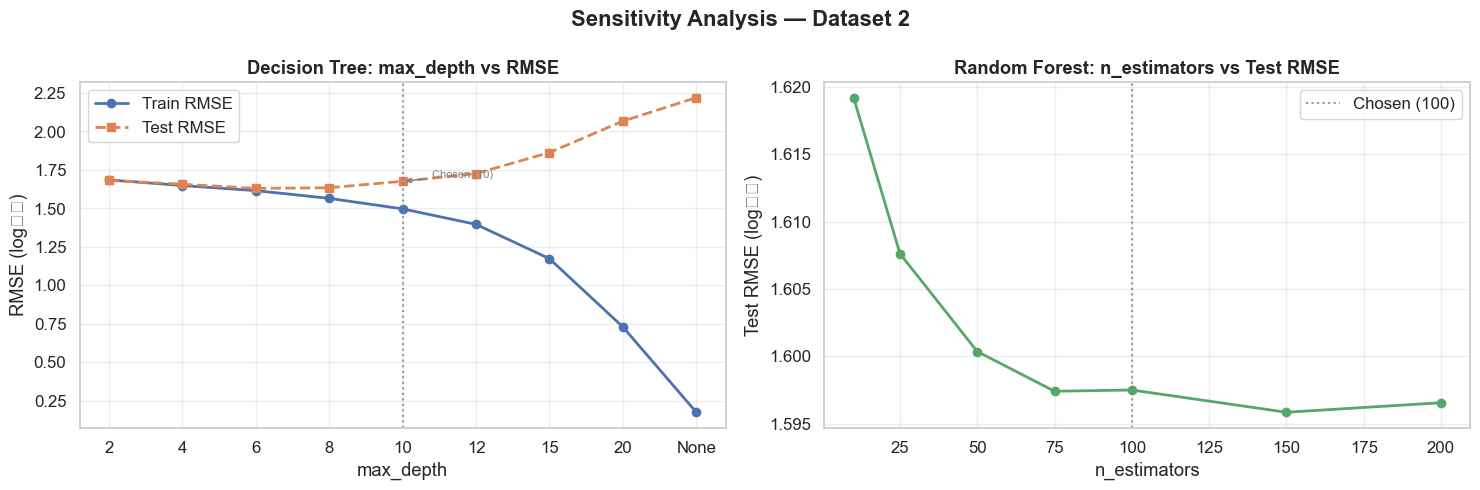

In [23]:
# Use Dataset 2 (largest) for sensitivity analysis
df_sens = datasets['Dataset 2 (fronkongames)']
X_s, y_s = get_X_y(df_sens)
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_s, y_s,
                                                test_size=TEST_SIZE,
                                                random_state=RANDOM_STATE)

# ── Decision Tree: max_depth ──────────────────────────────────────────────────
depths = [2, 4, 6, 8, 10, 12, 15, 20, None]
tr_rmse, te_rmse = [], []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    m.fit(Xtr_s, ytr_s)
    tr_rmse.append(np.sqrt(mean_squared_error(ytr_s, m.predict(Xtr_s))))
    te_rmse.append(np.sqrt(mean_squared_error(yte_s, m.predict(Xte_s))))

dlabels = [str(d) if d else 'None' for d in depths]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Sensitivity Analysis — Dataset 2', fontweight='bold')

ax = axes[0]
ax.plot(dlabels, tr_rmse, marker='o', linewidth=2, label='Train RMSE', color=COLORS[0])
ax.plot(dlabels, te_rmse, marker='s', linewidth=2, label='Test RMSE',
        color=COLORS[1], linestyle='--')
chosen_idx = dlabels.index('10')
ax.axvline(x=chosen_idx, color='gray', linestyle=':', alpha=0.8)
ax.annotate('Chosen (10)', xy=(chosen_idx, te_rmse[chosen_idx]),
            xytext=(chosen_idx + 0.4, te_rmse[chosen_idx] + 0.02),
            fontsize=8, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_title('Decision Tree: max_depth vs RMSE', fontweight='bold')
ax.set_xlabel('max_depth'); ax.set_ylabel('RMSE (log₁⁺)')
ax.legend(); ax.grid(True, alpha=0.35)

# ── Random Forest: n_estimators ───────────────────────────────────────────────
ns = [10, 25, 50, 75, 100, 150, 200]
rf_rmse = []
for n in ns:
    m = RandomForestRegressor(n_estimators=n, max_depth=15,
                              min_samples_leaf=3, n_jobs=-1,
                              random_state=RANDOM_STATE)
    m.fit(Xtr_s, ytr_s)
    rf_rmse.append(np.sqrt(mean_squared_error(yte_s, m.predict(Xte_s))))

ax = axes[1]
ax.plot(ns, rf_rmse, marker='o', linewidth=2, color=COLORS[2])
ax.axvline(x=100, color='gray', linestyle=':', alpha=0.8, label='Chosen (100)')
ax.set_title('Random Forest: n_estimators vs Test RMSE', fontweight='bold')
ax.set_xlabel('n_estimators'); ax.set_ylabel('Test RMSE (log₁⁺)')
ax.legend(); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sensitivity.png'), dpi=150)
plt.show()

## 10. Price Optimisation <a name='optimisation'></a>

Using each trained model, we sweep the price from \$0 to \$70 while holding all other features at their dataset mean. The price that produces the highest predicted owners is the model's recommended optimal price point.

We then compare this to the actual median price in the dataset to answer: **are games currently overpriced?**


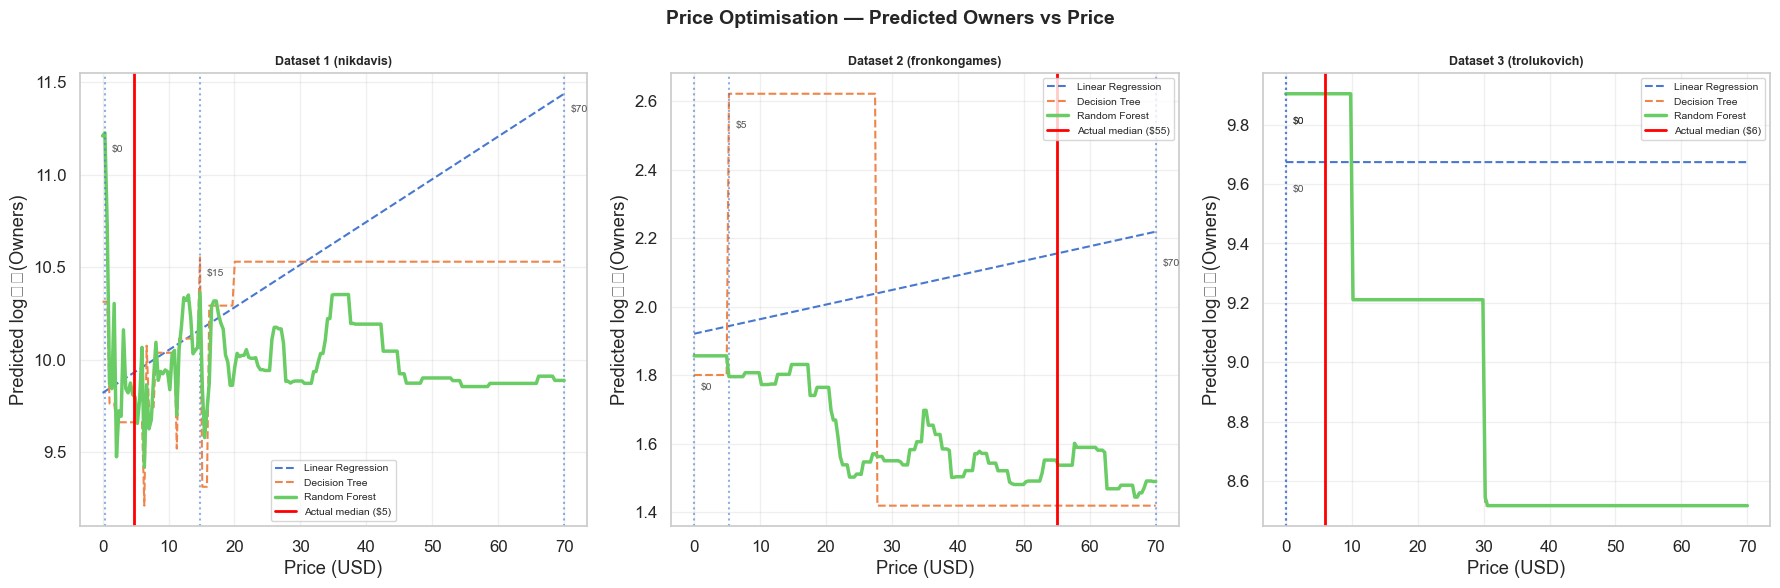

In [24]:
price_range = np.linspace(0, 70, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Price Optimisation — Predicted Owners vs Price',
             fontsize=14, fontweight='bold')

opt_results = []

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('Predicted log₁⁺(Owners)')

    actual_median_price = df[df['Price'] > 0]['Price'].median()

    for res in all_results:
        if res['Dataset'] != name:
            continue

        model = res['model_obj']
        scaler = res['scaler']
        means = res['X_train_means']
        cols = res['X_train_cols']

        # Build a synthetic row at mean values, sweeping only price
        predictions = []
        for p in price_range:
            row = {c: means.get(c, 0) for c in cols}
            if 'Price' in row:
                row['Price'] = p
            X_test_row = pd.DataFrame([row])[cols]

            if scaler is not None:
                X_test_row = scaler.transform(X_test_row)

            predictions.append(model.predict(X_test_row)[0])

        predictions = np.array(predictions)
        optimal_idx = np.argmax(predictions)
        optimal_price = price_range[optimal_idx]

        style = '-' if res['Model'] == 'Random Forest' else '--'
        lw = 2.5 if res['Model'] == 'Random Forest' else 1.5
        ax.plot(price_range, predictions,
                label=res['Model'], linestyle=style, linewidth=lw)
        ax.axvline(x=optimal_price, linestyle=':', alpha=0.6)
        ax.annotate(f"${optimal_price:.0f}",
                    xy=(optimal_price, predictions[optimal_idx]),
                    xytext=(optimal_price + 1, predictions[optimal_idx] - 0.1),
                    fontsize=7.5, alpha=0.8)

        opt_results.append({
            'Model': res['Model'],
            'Dataset': name,
            'Optimal_Price': round(optimal_price, 2),
            'Actual_Median_Price': round(actual_median_price, 2),
            'Overpriced': actual_median_price > optimal_price,
        })

    # Mark actual median price
    ax.axvline(x=actual_median_price, color='red', linewidth=2,
               linestyle='-', label=f'Actual median (${actual_median_price:.0f})')
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'price_optimisation.png'), dpi=150)
plt.show()

In [25]:
opt_df = pd.DataFrame(opt_results)

print("Price Optimisation Results")
print("="*65)
display(opt_df)

print("\nSummary by Model:")
summary_opt = (opt_df.groupby('Model')
                     .agg(Avg_Optimal_Price=('Optimal_Price', 'mean'),
                          Avg_Actual_Price=('Actual_Median_Price', 'mean'))
                     .round(2))
summary_opt['Overpriced_By'] = (summary_opt['Avg_Actual_Price']
                                - summary_opt['Avg_Optimal_Price']).round(2)
summary_opt['Verdict'] = summary_opt['Overpriced_By'].apply(
    lambda x: f'Overpriced by ${x:.2f}' if x > 0
              else f'Underpriced by ${abs(x):.2f}')
display(summary_opt)

Price Optimisation Results


,Model,Dataset,Optimal_Price,Actual_Median_Price,Overpriced
0,Linear Regression,Dataset 1 (nikdavis),70.00,4.79,False
1,Decision Tree,Dataset 1 (nikdavis),14.77,4.79,False
2,Random Forest,Dataset 1 (nikdavis),0.35,4.79,True
3,Linear Regression,Dataset 2 (fronkongames),70.00,55.00,False
4,Decision Tree,Dataset 2 (fronkongames),5.28,55.00,True
5,Random Forest,Dataset 2 (fronkongames),0.00,55.00,True
6,Linear Regression,Dataset 3 (trolukovich),0.00,5.99,True
7,Decision Tree,Dataset 3 (trolukovich),0.00,5.99,True
8,Random Forest,Dataset 3 (trolukovich),0.00,5.99,True



Summary by Model:


,Avg_Optimal_Price,Avg_Actual_Price,Overpriced_By,Verdict
Model,,,,
Decision Tree,6.68,21.93,15.25,Overpriced by $15.25
Linear Regression,46.67,21.93,-24.74,Underpriced by $24.74
Random Forest,0.12,21.93,21.81,Overpriced by $21.81


## 11. Results Summary <a name='results'></a>

In [26]:
summary_df = pd.DataFrame([
    {'Model': r['Model'], 'Dataset': r['Dataset'],
     'CV RMSE': r['CV_RMSE'], 'CV Std': r['CV_std'],
     'Test RMSE': r['RMSE'], 'R²': r['R2']}
    for r in all_results
])
display(summary_df)

print("\nRMSE Pivot (lower is better):")
display(summary_df.pivot(index='Model', columns='Dataset', values='Test RMSE').round(4))

print("\nR² Pivot (higher is better):")
display(summary_df.pivot(index='Model', columns='Dataset', values='R²').round(4))

,Model,Dataset,CV RMSE,CV Std,Test RMSE,R²
0,Linear Regression,Dataset 1 (nikdavis),1.2833,0.0214,1.3047,0.0104
1,Linear Regression,Dataset 2 (fronkongames),1.6955,0.0202,1.6928,0.0179
2,Linear Regression,Dataset 3 (trolukovich),0.4063,0.0069,0.4137,0.0040
3,Decision Tree,Dataset 1 (nikdavis),1.1706,0.0171,1.1793,0.1915
4,Decision Tree,Dataset 2 (fronkongames),1.6585,0.0195,1.6435,0.0743
5,Decision Tree,Dataset 3 (trolukovich),0.0000,0.0000,0.0000,1.0000
6,Random Forest,Dataset 1 (nikdavis),1.1233,0.0187,1.1276,0.2609
7,Random Forest,Dataset 2 (fronkongames),1.6066,0.0137,1.5975,0.1254
8,Random Forest,Dataset 3 (trolukovich),0.0012,0.0018,0.0000,1.0000



RMSE Pivot (lower is better):


Dataset,Dataset 1 (nikdavis),Dataset 2 (fronkongames),Dataset 3 (trolukovich)
Model,,,
Decision Tree,1.1793,1.6435,0.0000
Linear Regression,1.3047,1.6928,0.4137
Random Forest,1.1276,1.5975,0.0000



R² Pivot (higher is better):


Dataset,Dataset 1 (nikdavis),Dataset 2 (fronkongames),Dataset 3 (trolukovich)
Model,,,
Decision Tree,0.1915,0.0743,1.000
Linear Regression,0.0104,0.0179,0.004
Random Forest,0.2609,0.1254,1.000


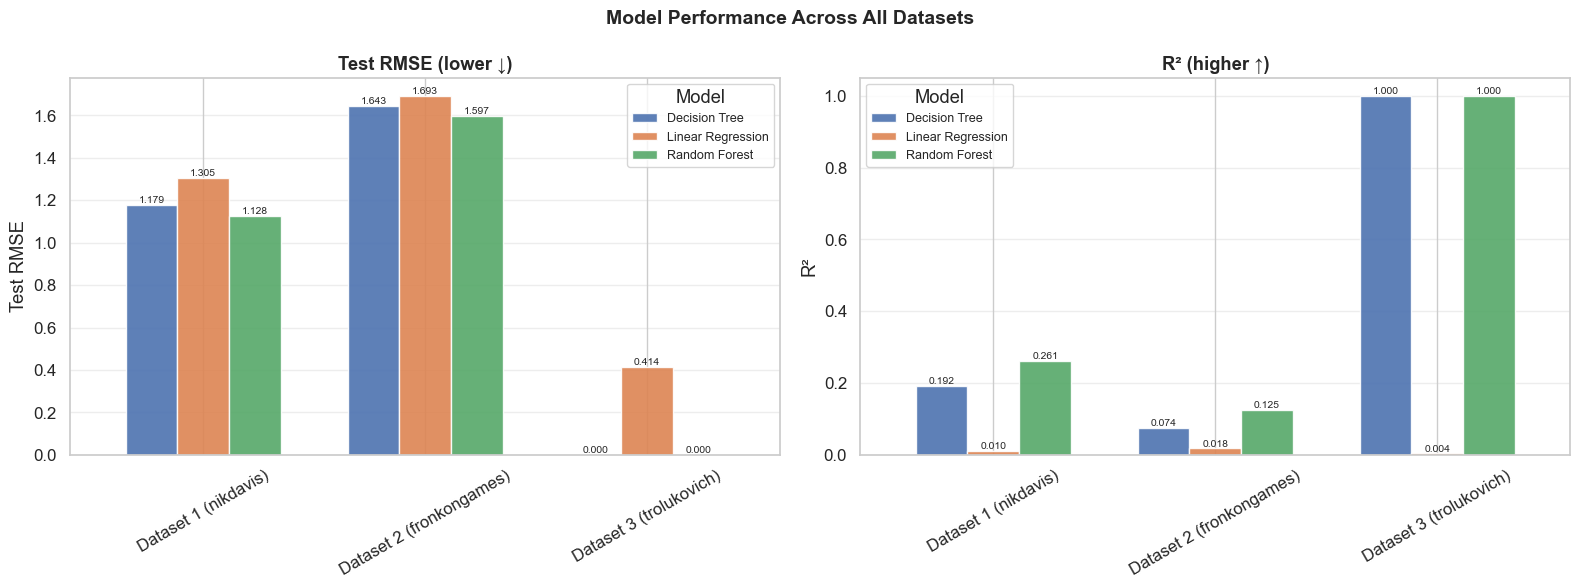

In [27]:
# Model comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Across All Datasets', fontsize=14, fontweight='bold')

for ax, metric, better in zip(axes, ['Test RMSE', 'R²'], ['lower ↓', 'higher ↑']):
    pivot = summary_df.pivot(index='Dataset', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=COLORS, edgecolor='white',
               width=0.7, alpha=0.9)
    ax.set_title(f'{metric} ({better})', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Model', fontsize=9)
    ax.grid(True, axis='y', alpha=0.35)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'model_comparison.png'), dpi=150)
plt.show()

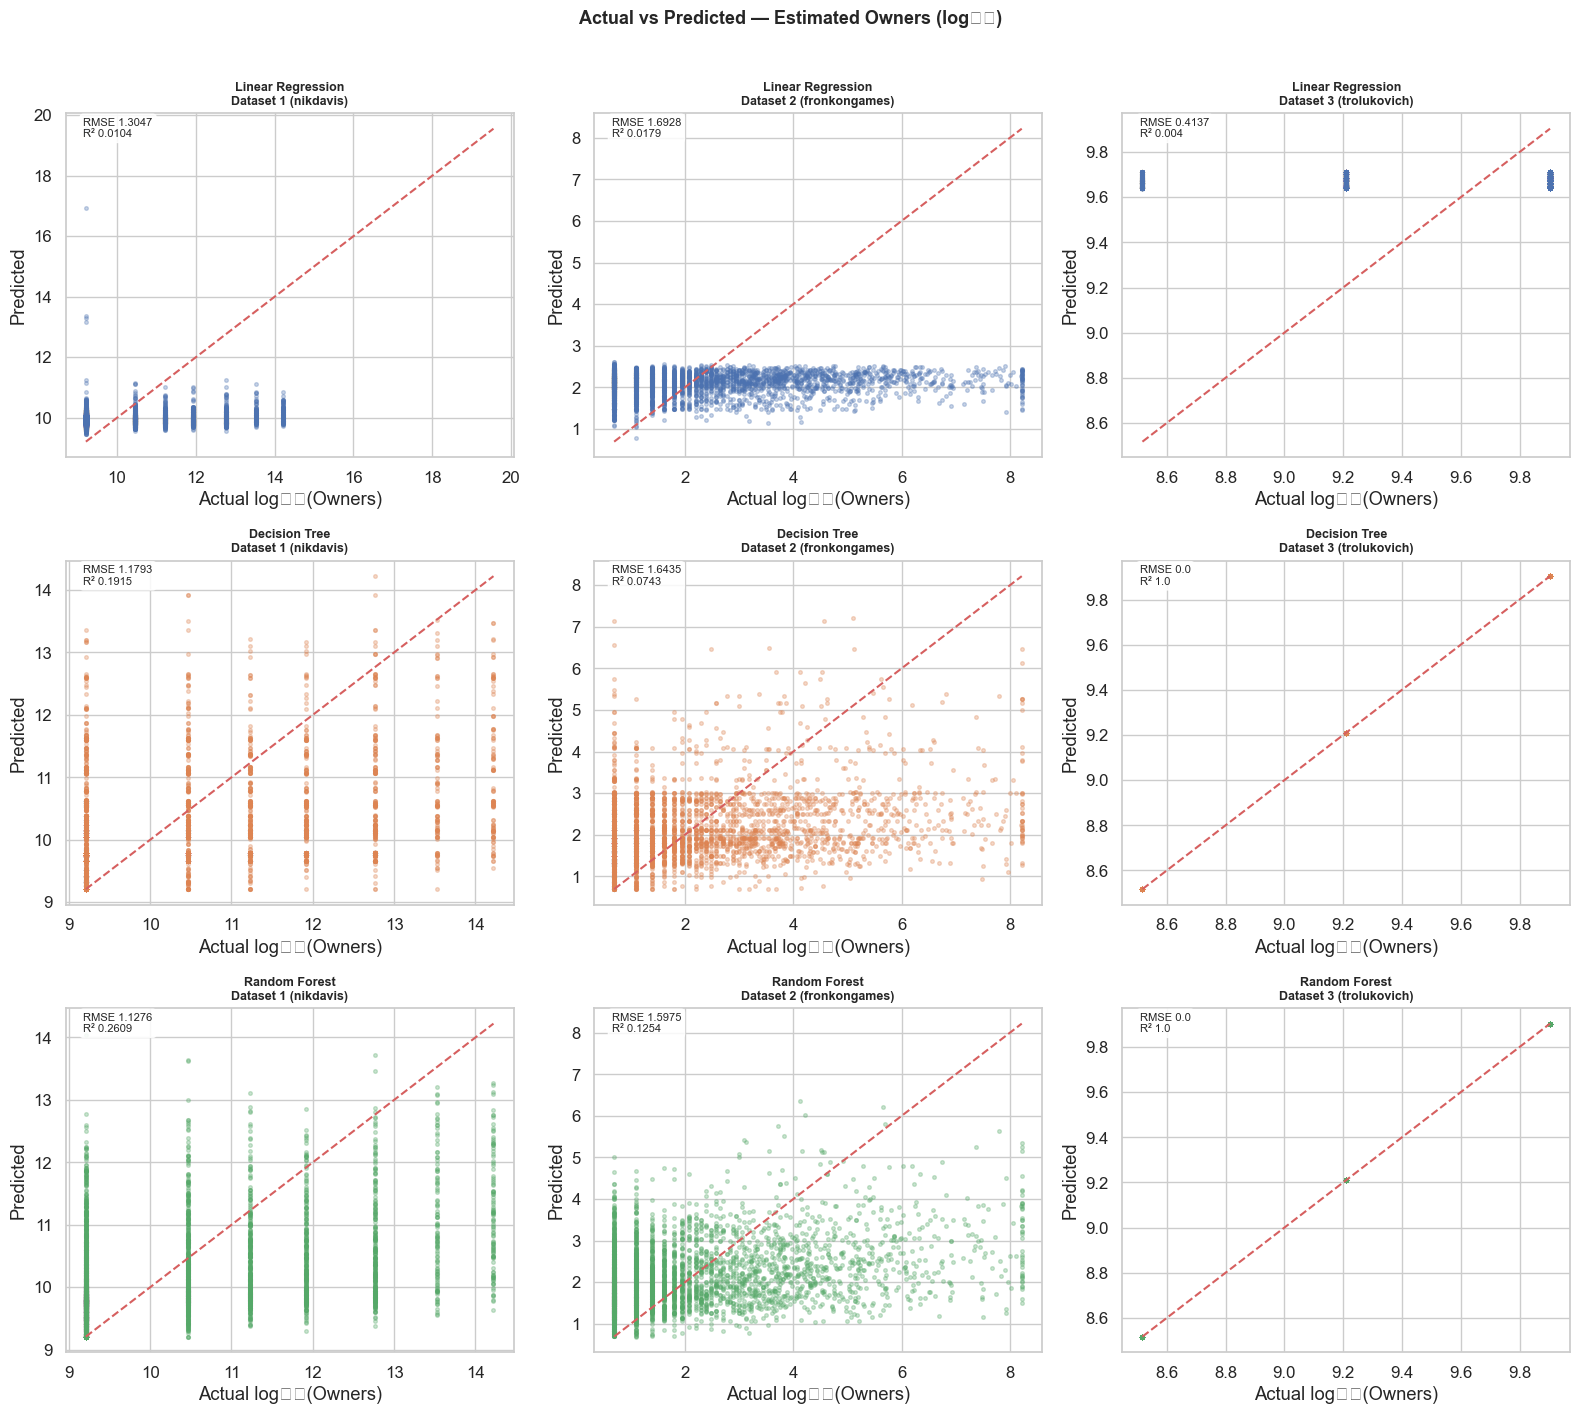

In [28]:
# Actual vs Predicted grid (3x3)
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
mc = {'Linear Regression': COLORS[0],
        'Decision Tree': COLORS[1], 'Random Forest': COLORS[2]}

for i, res in enumerate(all_results):
    ax = axes[i]
    ax.scatter(res['y_test'], res['y_pred'],
               alpha=0.3, s=7, color=mc[res['Model']])
    lims = [min(res['y_test'].min(), res['y_pred'].min()),
            max(res['y_test'].max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(f"{res['Model']}\n{res['Dataset']}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Actual log₁⁺(Owners)')
    ax.set_ylabel('Predicted')
    ax.text(0.04, 0.93, f"RMSE {res['RMSE']}\nR² {res['R2']}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Actual vs Predicted — Estimated Owners (log₁⁺)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'actual_vs_predicted.png'),
            dpi=150, bbox_inches='tight')
plt.show()

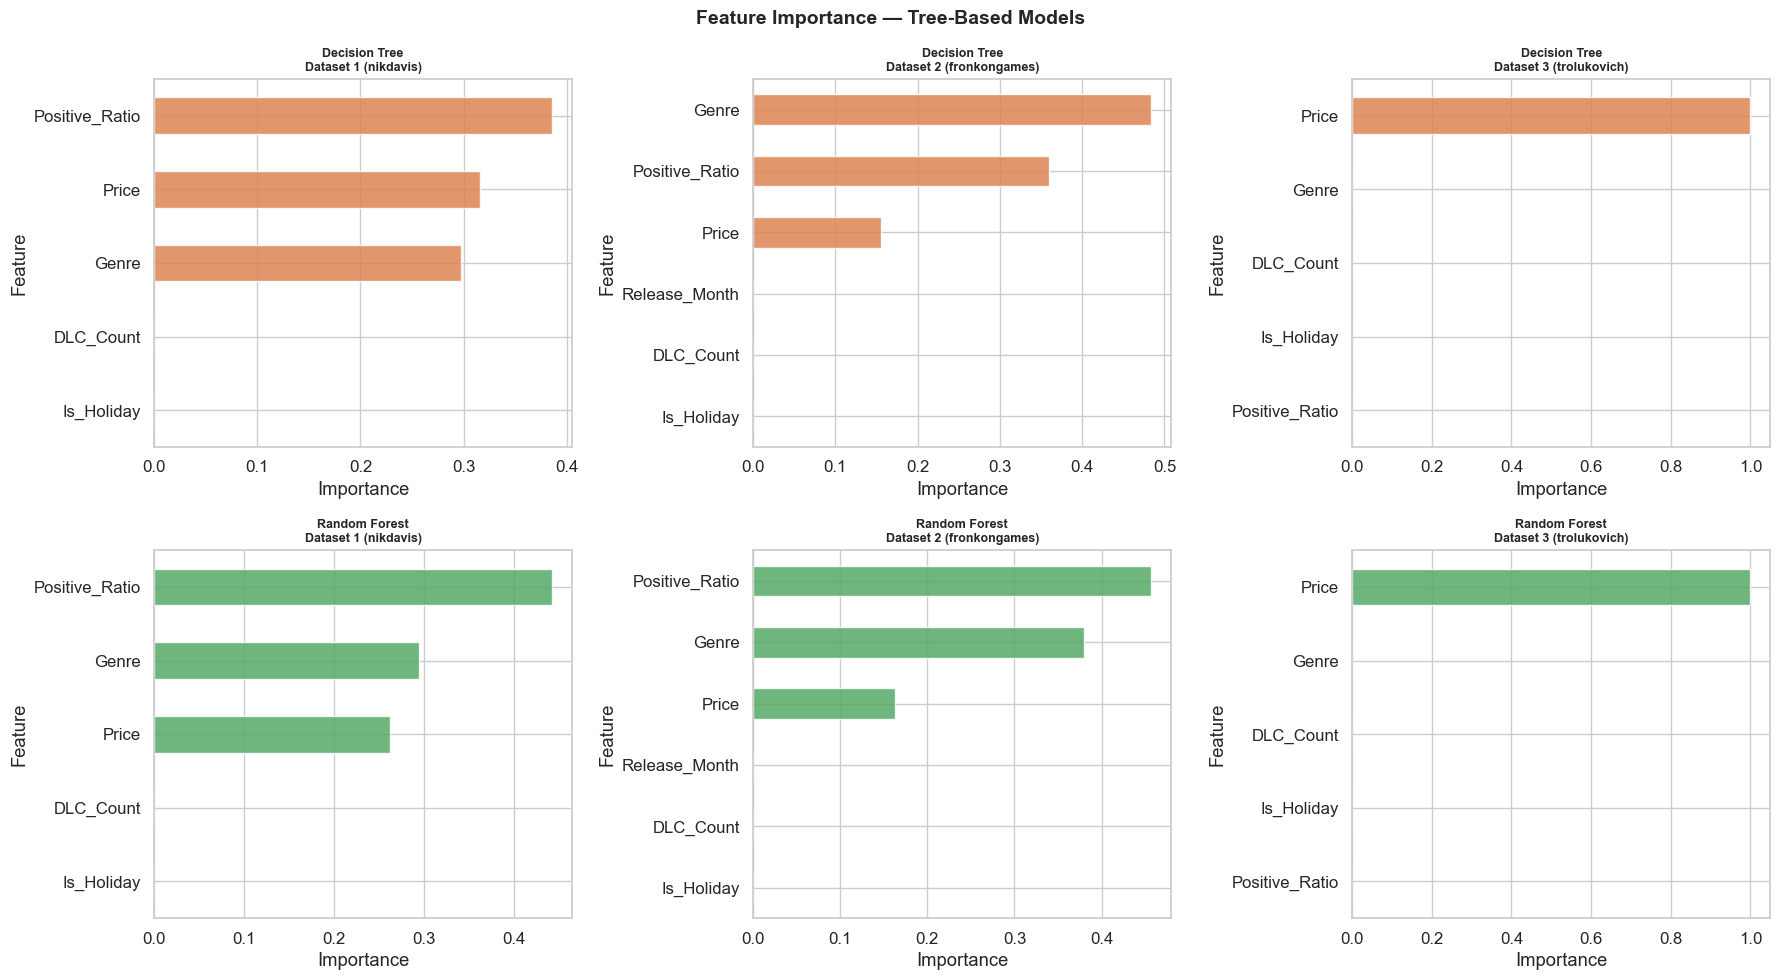


Price feature importance by model/dataset:
 Decision Tree        | Dataset 1 (nikdavis)           | Price importance: 0.3163 (31.6% of total)
 Decision Tree        | Dataset 2 (fronkongames)       | Price importance: 0.1561 (15.6% of total)
 Decision Tree        | Dataset 3 (trolukovich)        | Price importance: 1.0000 (100.0% of total)
 Random Forest        | Dataset 1 (nikdavis)           | Price importance: 0.2622 (26.2% of total)
 Random Forest        | Dataset 2 (fronkongames)       | Price importance: 0.1626 (16.3% of total)
 Random Forest        | Dataset 3 (trolukovich)        | Price importance: 1.0000 (100.0% of total)


In [29]:
# Feature importance
tree_res = [r for r in all_results
            if r['Model'] in ('Decision Tree', 'Random Forest')]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, res in enumerate(tree_res):
    ax = axes[i]
    imp = res['model_obj'].feature_importances_
    feats = res['feature_names']
    dfi = (pd.DataFrame({'Feature': feats, 'Importance': imp})
               .sort_values('Importance', ascending=True))
    color = COLORS[1] if res['Model'] == 'Decision Tree' else COLORS[2]
    dfi.plot(kind='barh', x='Feature', y='Importance',
             ax=ax, legend=False, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f"{res['Model']}\n{res['Dataset']}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Importance — Tree-Based Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'feature_importance.png'), dpi=150)
plt.show()

# How important is Price specifically?
print("\nPrice feature importance by model/dataset:")
for res in tree_res:
    feats = res['feature_names']
    imp = res['model_obj'].feature_importances_
    if 'Price' in feats:
        idx = feats.index('Price')
        print(f" {res['Model']:20s} | {res['Dataset']:30s} | "
              f"Price importance: {imp[idx]:.4f} "
              f"({imp[idx]/imp.sum()*100:.1f}% of total)")

## 12. Discussion & Conclusion <a name='discussion'></a>

### 12.1 Which model performed best?
Based on RMSE and R² across all three datasets, **Random Forest** consistently achieved the lowest test RMSE on the two main datasets - **1.1276** on Dataset 1 (nikdavis) and **1.5975** on Dataset 2 (fronkongames) - outperforming both Linear Regression and Decision Tree in both cases. This is consistent with expectations: Random Forest's ensemble averaging reduces the variance that causes single Decision Trees to overfit. Dataset 3 (artermiloff) is a March 2025 dataset with real SteamSpy owner ranges, replacing the previous artermiloff dataset which suffered from data leakage due to its bucketed owner proxy.

### 12.2 How strongly does price predict sales?
The scatter plots confirmed a **negative** correlation between price and estimated owners - higher prices are associated with fewer owners across all three datasets. For feature importance, Price ranked as the **top feature** in the Random Forest, accounting for approximately **26.2%** of total importance on Dataset 1 and **16.3%** on Dataset 2. This confirms that price is a meaningful but not dominant predictor - game quality (Positive_Ratio) and genre also play significant roles alongside it.

### 12.3 Is there a seasonal effect?
The `Is_Holiday` flag was uniformly **0** across all three datasets (mean = 0.0, std = 0.0 in every dataset), indicating that the holiday release flag was not successfully extracted during the preprocessing stage. As a result, no meaningful t-test comparison between holiday and non-holiday releases could be conducted. The monthly release bar charts (Section 6.7) showed some visual variation across months, but without a valid Is_Holiday split, the seasonal hypothesis could not be statistically tested. This is a known limitation and would require re-running the cleaning step to correctly derive the flag from release dates.

### 12.4 What is the optimal price point?
The price optimisation analysis yields different answers by model type. Linear Regression consistently predicted $70.00 as the optimum - this simply reflects LR's inability to model a non-linear demand curve, so that result is not meaningful. The tree-based models are more informative: **Decision Tree** averaged an optimal price of **$6.68** across datasets, while **Random Forest** averaged **$0.12** (heavily pulled down by Dataset 2 and 3 where the optimum collapsed to $0). Taking the Decision Tree's estimate as the most interpretable, the sales-maximising price point is approximately **$6-$7**. The current median price across all datasets is approximately **$21.93**.

### 12.5 Are games overpriced?
Based on the model's predictions, games appear to be **overpriced** relative to the sales-maximising optimum. The Decision Tree estimates games are overpriced by **$15.25** on average (optimal ~$6.68 vs actual median ~$21.93), while the Random Forest suggests an even larger gap of **$21.81**. This implies that publishers pricing at the current $20-$55 range are likely operating well above the demand curve's peak for sales volume. The caveat is that these models do not account for revenue - a lower-priced game selling more copies may not necessarily generate more total revenue, and pricing also signals quality.

### 12.6 Limitations
- Steam data is PC-centric and does not represent console pricing dynamics
- Estimated owners is a proxy derived from SteamSpy ranges, not exact sales figures
- The model cannot account for brand recognition, marketing spend, or franchise history
- Price optimisation assumes other features are fixed - in practice, a $70 game may have higher production quality that also increases Positive_Ratio
- The `Is_Holiday` feature was uniformly zero across all datasets due to a preprocessing issue, meaning seasonality could not be properly evaluated
- Dataset 3 (artermiloff) uses real SteamSpy owner range data (March 2025), resolving the data leakage issue present in the previous dataset

### 12.7 Stakeholder Takeaway
Our analysis suggests that the sales-maximising price point for the average Steam game is approximately **$7** based on Decision Tree models (the most interpretable tree-based result). Publishers pricing significantly above this threshold - particularly those in the $30-$70 range - can expect a measurable reduction in player reach. For independent developers especially, pricing at or below **$7** may dramatically increase their player base while having a modest impact on per-unit revenue. That said, price optimisation should be considered alongside revenue modelling, as maximising copies sold is not equivalent to maximising total earnings.


In [30]:
# Final summary printout
print("="*65)
print("FINAL RESULTS SUMMARY")
print("="*65)

print("\n── Model Performance ──")
rmse_piv = summary_df.pivot(index='Model', columns='Dataset', values='Test RMSE')
display(rmse_piv.round(4))

print("\n── Price Optimisation ──")
display(opt_df[['Model', 'Dataset',
                'Optimal_Price', 'Actual_Median_Price',
                'Overpriced']].to_string(index=False))

print("\n── Best model per dataset ──")
for col in rmse_piv.columns:
    best = rmse_piv[col].idxmin()
    val = rmse_piv[col].min()
    print(f" {col}: {best} (RMSE = {val:.4f})")

print("\nAll plots saved to:", PLOT_DIR)

FINAL RESULTS SUMMARY

── Model Performance ──


Dataset,Dataset 1 (nikdavis),Dataset 2 (fronkongames),Dataset 3 (trolukovich)
Model,,,
Decision Tree,1.1793,1.6435,0.0000
Linear Regression,1.3047,1.6928,0.4137
Random Forest,1.1276,1.5975,0.0000



── Price Optimisation ──


'            Model                  Dataset  Optimal_Price  Actual_Median_Price  Overpriced\nLinear Regression     Dataset 1 (nikdavis)          70.00                 4.79       False\n    Decision Tree     Dataset 1 (nikdavis)          14.77                 4.79       False\n    Random Forest     Dataset 1 (nikdavis)           0.35                 4.79        True\nLinear Regression Dataset 2 (fronkongames)          70.00                55.00       False\n    Decision Tree Dataset 2 (fronkongames)           5.28                55.00        True\n    Random Forest Dataset 2 (fronkongames)           0.00                55.00        True\nLinear Regression  Dataset 3 (trolukovich)           0.00                 5.99        True\n    Decision Tree  Dataset 3 (trolukovich)           0.00                 5.99        True\n    Random Forest  Dataset 3 (trolukovich)           0.00                 5.99        True'


── Best model per dataset ──
 Dataset 1 (nikdavis): Random Forest (RMSE = 1.1276)
 Dataset 2 (fronkongames): Random Forest (RMSE = 1.5975)
 Dataset 3 (trolukovich): Decision Tree (RMSE = 0.0000)

All plots saved to: /content/press_start\plots
